# 1 - Evaluación del modelo
Evaluamos el modelo entrenado sobre el conjunto de test, analizamos la matriz de confusión e identificamos los errores más frecuentes.

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms, models
from torch import nn
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

Usando: cuda


# 2 - Carga del modelo y dataset
Cargamos el mejor modelo guardado durante el entrenamiento y preparamos el dataset de test.

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 38
DATASET_PATH = "plantvillage dataset/color"

# mismas transformaciones de validación (sin augmentación)
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# carga el dataset completo para obtener los nombres de las clases
dataset_completo = datasets.ImageFolder(root=DATASET_PATH, transform=test_transforms)
nombres_clases = dataset_completo.classes

# recrea el mismo split con la misma seed para obtener el mismo test set
total = len(dataset_completo)
train_size = int(0.8 * total)
val_size = int(0.1 * total)
test_size = total - train_size - val_size

_, _, test_dataset = random_split(
    dataset_completo,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# carga la arquitectura y los pesos del mejor modelo guardado
modelo = models.efficientnet_b0(weights=None)
num_features = modelo.classifier[1].in_features
modelo.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, NUM_CLASSES)
)
modelo.load_state_dict(torch.load("mejor_modelo.pth", map_location=device, weights_only=True))
modelo = modelo.to(device)
modelo.eval()

print(f"Modelo cargado correctamente")
print(f"Imágenes de test: {test_size:,}")

Modelo cargado correctamente
Imágenes de test: 5,431


# 3 - Evaluación en el conjunto de test
Pasamos todas las imágenes de test por el modelo y recogemos 
las predicciones reales vs las esperadas.

In [4]:
todas_predicciones = []
todas_etiquetas = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(device)

        # el modelo devuelve un score por cada clase
        # argmax(1) elige la clase con mayor score
        predicciones = modelo(imagenes).argmax(1)

        todas_predicciones.extend(predicciones.cpu().numpy())
        todas_etiquetas.extend(etiquetas.numpy())

# convierte a arrays de numpy para usar con sklearn
todas_predicciones = np.array(todas_predicciones)
todas_etiquetas = np.array(todas_etiquetas)

# accuracy global en test
accuracy_test = (todas_predicciones == todas_etiquetas).mean()
print(f"Accuracy en test: {accuracy_test:.4f} ({accuracy_test*100:.2f}%)")

Accuracy en test: 0.9683 (96.83%)


# 4 - Matriz de confusión
Visualizamos qué clases se confunden entre sí. Las celdas más oscuras 
fuera de la diagonal indican errores frecuentes.

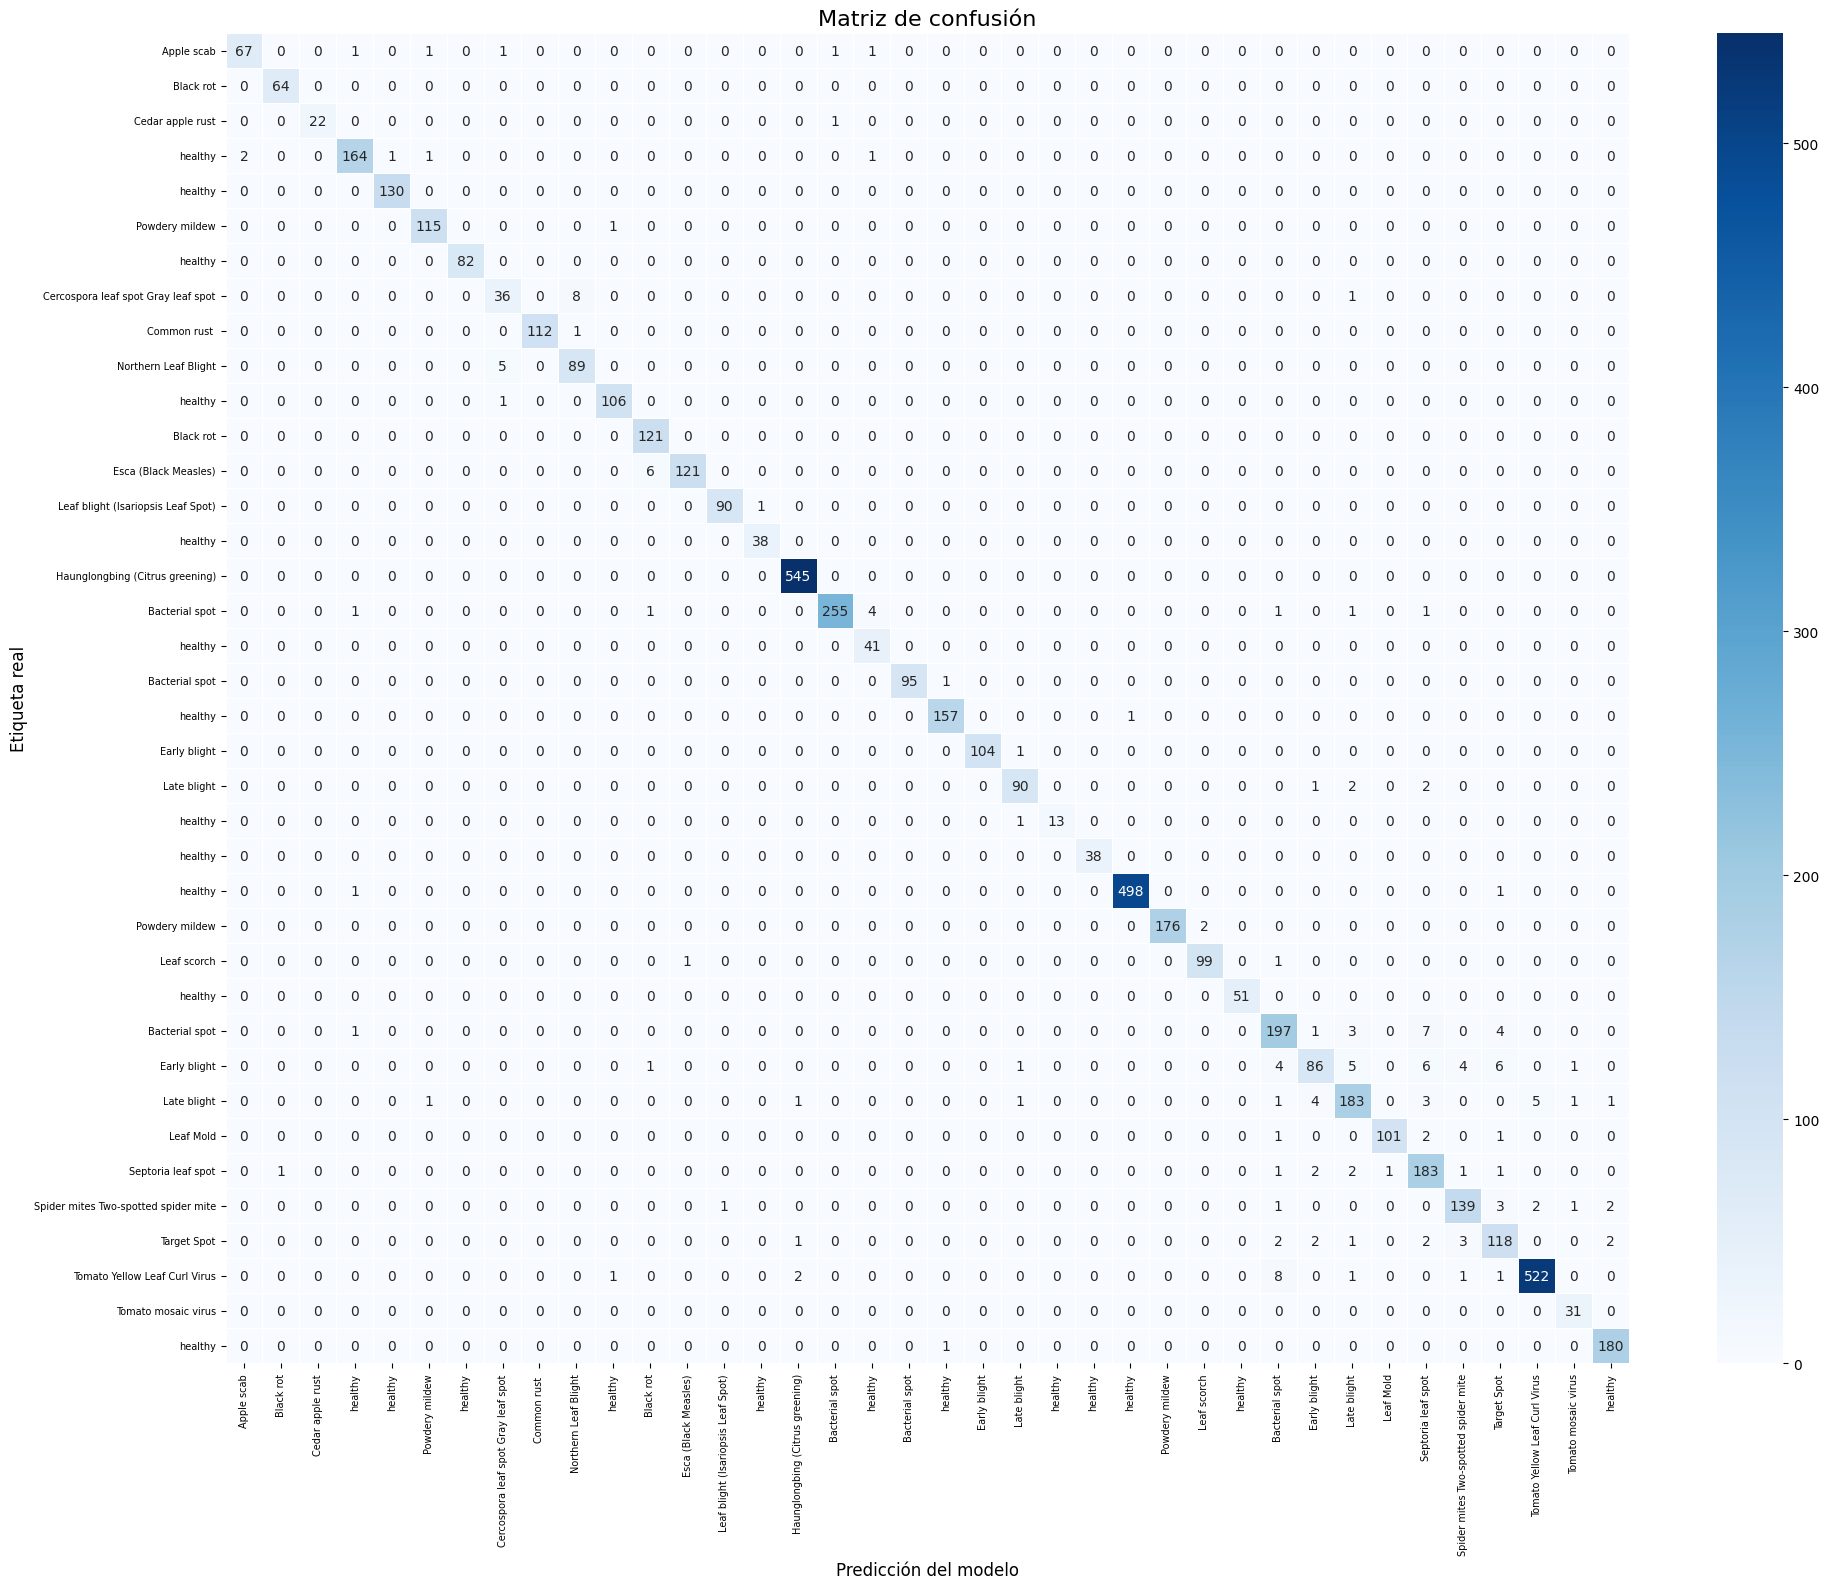

In [5]:
# calcula la matriz de confusión
matriz = confusion_matrix(todas_etiquetas, todas_predicciones)

# nombres cortos para que quepan en la gráfica
nombres_cortos = [nombre.split("___")[1].replace("_", " ") for nombre in nombres_clases]

plt.figure(figsize=(20, 16))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nombres_cortos,
    yticklabels=nombres_cortos,
    linewidths=0.5
)
plt.title("Matriz de confusión", fontsize=16)
plt.ylabel("Etiqueta real", fontsize=12)
plt.xlabel("Predicción del modelo", fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# 5 - Reporte por clase
Accuracy, precisión y recall para cada una de las 38 enfermedades.

In [6]:
reporte = classification_report(
    todas_etiquetas,
    todas_predicciones,
    target_names=nombres_cortos
)
print(reporte)

                                      precision    recall  f1-score   support

                          Apple scab       0.97      0.93      0.95        72
                           Black rot       0.98      1.00      0.99        64
                    Cedar apple rust       1.00      0.96      0.98        23
                             healthy       0.98      0.97      0.97       169
                             healthy       0.99      1.00      1.00       130
                      Powdery mildew       0.97      0.99      0.98       116
                             healthy       1.00      1.00      1.00        82
 Cercospora leaf spot Gray leaf spot       0.84      0.80      0.82        45
                        Common rust        1.00      0.99      1.00       113
                Northern Leaf Blight       0.91      0.95      0.93        94
                             healthy       0.98      0.99      0.99       107
                           Black rot       0.94      1.00      

# 6 - Análisis de errores
Visualizamos las imágenes donde el modelo falló para entender sus limitaciones.

Total errores: 172 de 5431 imágenes


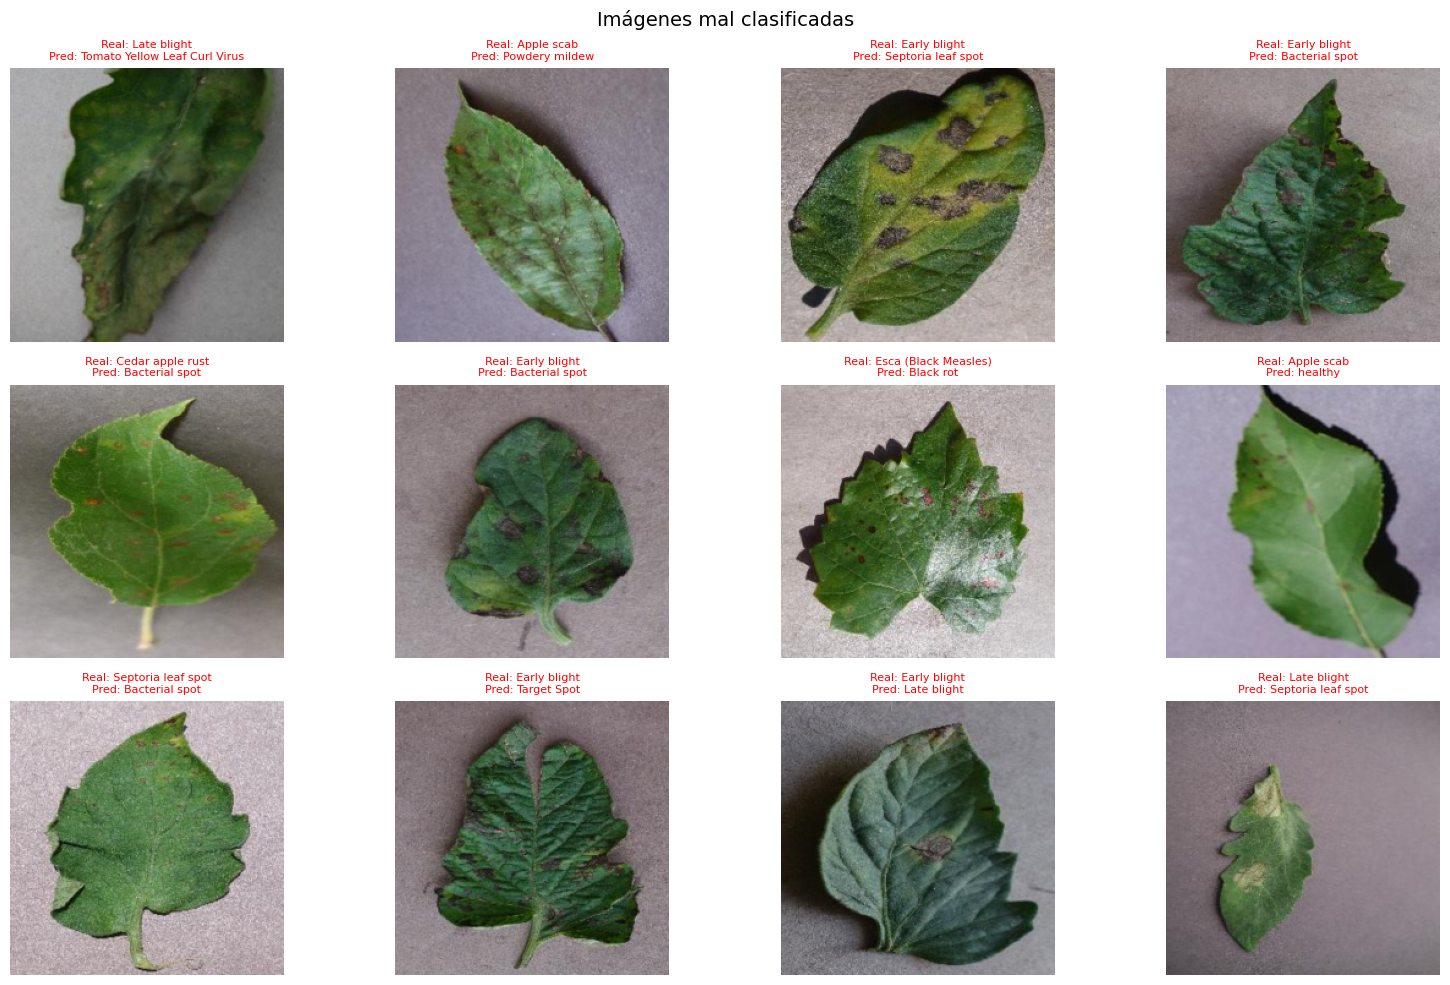

In [7]:
# recoge imágenes mal clasificadas
imagenes_error = []

modelo.eval()
with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(device)
        predicciones = modelo(imagenes).argmax(1).cpu()

        for i in range(len(etiquetas)):
            if predicciones[i] != etiquetas[i]:
                imagenes_error.append({
                    "imagen": imagenes[i].cpu(),
                    "real": nombres_clases[etiquetas[i]].split("___")[1].replace("_", " "),
                    "prediccion": nombres_clases[predicciones[i]].split("___")[1].replace("_", " ")
                })

print(f"Total errores: {len(imagenes_error)} de {test_size} imágenes")

# muestra los primeros 12 errores
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

# desnormaliza la imagen para visualizarla correctamente
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, error in enumerate(imagenes_error[:12]):
    img = error["imagen"] * std + mean
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img)
    axes[i].set_title(f"Real: {error['real']}\nPred: {error['prediccion']}", fontsize=8, color="red")
    axes[i].axis("off")

plt.suptitle("Imágenes mal clasificadas", fontsize=14)
plt.tight_layout()
plt.show()